In [7]:
import pandas as pd
from pyprojroot import here
import numpy as np
from pathlib import Path

from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import kruskal, ranksums

In [2]:
TARGET = 'occ'
true_matrix = pd.read_csv(
    here() / f'data/processed/true_matrices/{TARGET}.csv',
    index_col='datetime',
    parse_dates=True
)

In [3]:
result_list = list()
error_list = list()
data_path = Path('data/processed/prediction_matrices/')

for p in here(data_path / '50').glob('*1.csv'):
    
    result = dict()
    
    parts = p.stem.split('-')
    
    result['Model'] = parts[1]
    result['FS'] = parts[2]
    name = parts[1] + '-' + parts[2]
    
    pred_matrix = pd.read_csv(
        p, 
        index_col='datetime', 
        parse_dates=True)
    
    idx = pred_matrix.dropna().index.intersection(true_matrix.dropna().index)

    pred_matrix = pred_matrix.loc[idx]
    true_matrix = true_matrix.loc[idx]
    
    true = true_matrix.groupby(true_matrix.index.month).apply(flatten).to_dict()
    pred = pred_matrix.groupby(pred_matrix.index.month).apply(flatten).to_dict()
    
    for month in range(1,13):
        rmse = mean_squared_error(true[month], pred[month])
        result[month] = rmse
        
    result_list.append(result)

In [4]:
df = pd.DataFrame(result_list)

df = df.round(0)
df.Model.replace(name_mask, inplace=True)
df.FS = df.FS.str.upper()

df['Mean'] = df.iloc[:,2:].mean(axis=1)
df = df.sort_values(by='Mean', ascending=False)
df = df.drop(columns='Mean')

AttributeError: 'DataFrame' object has no attribute 'Model'

In [7]:
df.iloc[:,2:] = df.iloc[:,2:].astype(int)

/tmp/ipykernel_24160/1518682526.py:1: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  df.iloc[:,2:] = df.iloc[:,2:].astype(int)


In [ ]:
df.to_latex(
    buf = here() / 'output/tables/monthly_performance.tex',
    #float_format='%.0f',
    column_format='rp{5pt}p{5pt}p{5pt}p{5pt}p{5pt}p{5pt}p{5pt}p{5pt}p{5pt}p{5pt}p{5pt}p{5pt}p{5pt}',
    label='tab:monthly_performance',
    caption='Monthly performance of the tested models in RMSE.\
    FS = feature set',
    position='H',
    index=False,
    na_rep='-'
)

In [10]:
# Plot
df['Model'] = df['Model'] + '-' + df['FS']
df = df.drop(columns='FS')
df = df.set_index('Model')

dict_keys(['occ', 'Hour', 'Traffic', 'Calendar', 'Website_visits', 'Month', 'Weather', 'Events', 'TA', 'Holiday_name', 'Weekday', 'Trends', 'Beds'])


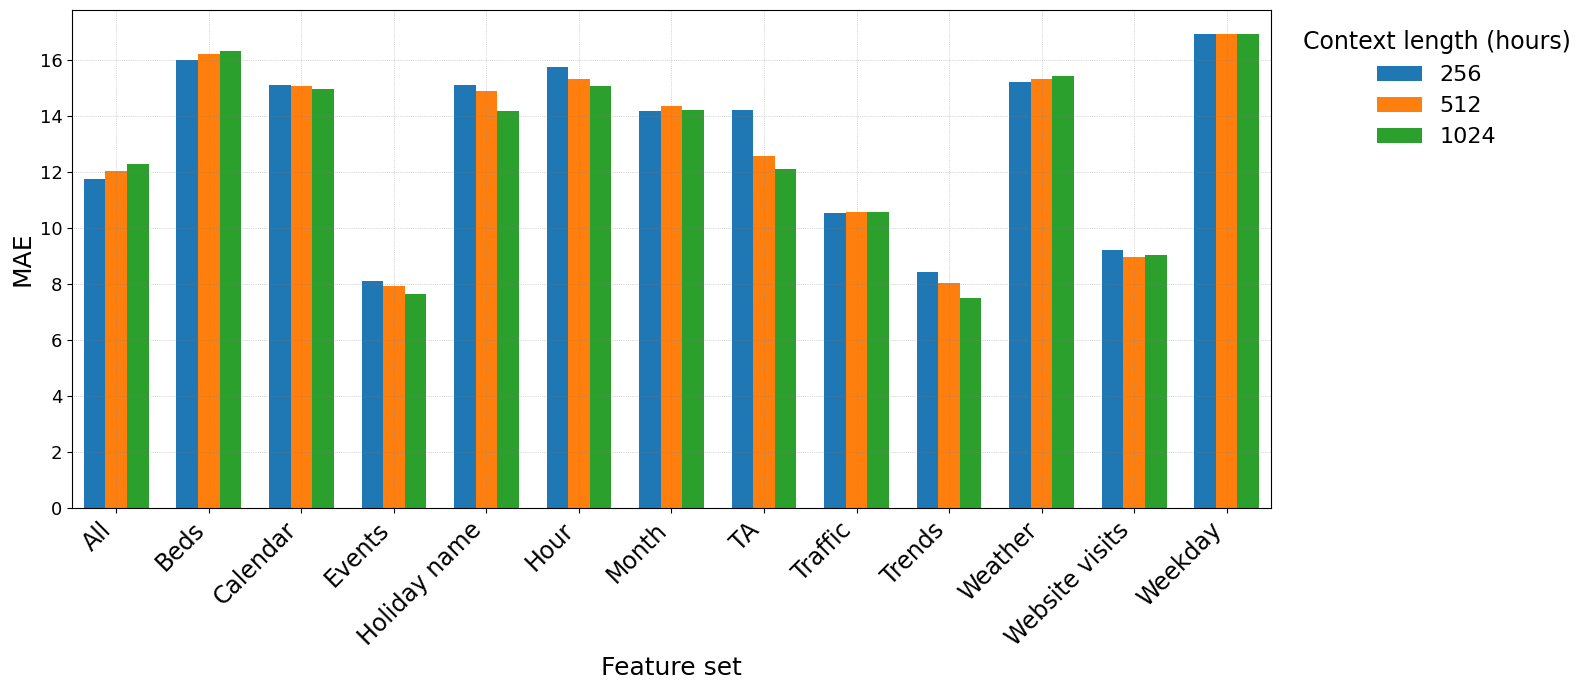

In [ ]:
import matplotlib.pyplot as plt

# Data setup
data_path = Path('data/processed/')
context_lengths = [256, 512, 1024]
subsets = [
    "Beds",
    "Calendar",
    "Events",
    "Holiday_name",
    "Hour",
    "Month",
    "TA",
    "Traffic",
    "Trends",
    "Weather",
    "Weekday",
    "Website_visits",
    "occ",
    # Add or remove as needed
]
results = {}  # {featureset: {cl: rmse for cl in context_lengths}}

for p in here(data_path / '50').glob('*-a-*.csv'):
    parts = p.stem.split('-')
    featureset = parts[0]  # e.g., "('Trends', 'Events', 'Website_visits')"
    model = parts[1]       # Assuming moirai2 for all
    fs = parts[2]          # 'a'
    cl_str = parts[3]
    cl = int(cl_str)
    
    if cl not in context_lengths or featureset not in subsets:
        continue
    
    pred_matrix = pd.read_csv(p, index_col='datetime', parse_dates=True)
    idx = pred_matrix.dropna().index.intersection(true_matrix.dropna().index)
    pred_matrix = pred_matrix.loc[idx]
    true_matrix = true_matrix.loc[idx]
    
    pred_vector = pred_matrix.to_numpy().ravel()
    true_vector = true_matrix.to_numpy().ravel()
    
    #rmse = np.sqrt(mean_squared_error(pred_vector, true_vector))
    mae = mean_absolute_error(pred_vector, true_vector)
    if featureset not in results:
        results[featureset] = {}
    results[featureset][cl] = mae
print(results.keys())
results['All'] = results.pop('occ')
results['Holiday name'] = results.pop('Holiday_name')
results['Website visits'] = results.pop('Website_visits')

# Simplify featureset names (remove quotes and parentheses for labels)
featuresets = sorted(results.keys())
labels = [fs.strip("()").replace("'", "").replace(", ", " + ") for fs in featuresets]

# Prepare data for bar chart
bar_width = 0.2
fig, ax = plt.subplots(figsize=(16, 7))

# Make bars thinner and closely packed (less margin, less bar width)
group_space = 0.0  # small gap between feature sets
total_bar_width = 1.0 - group_space
bar_width = total_bar_width / len(context_lengths) * 0.7  # 0.7 is a "thinness" factor

for i, cl in enumerate(context_lengths):
    rmses = [results[fs].get(cl, 0) for fs in featuresets]
    x_pos = np.arange(len(featuresets)) + (i - (len(context_lengths)-1)/2) * bar_width
    ax.bar(x_pos, rmses, width=bar_width, label=f'{cl}')

ax.set_xticks(np.arange(len(featuresets)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=17)
ax.tick_params(axis='y', labelsize=13)
legend = ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False, fontsize=16, title="Context length (hours)")
if legend and legend.get_title():
    legend.get_title().set_fontsize(17)
ax.set_ylabel('MAE', fontsize=18)
ax.set_xlabel('Feature set', fontsize=18)
ax.grid(lw=0.5, ls=':', color='gray', alpha=0.6)
ax.set_ylim(bottom=0)
ax.margins(x=0.01)

plt.savefig(here() / f'output/plots/multivar_mae.pdf', bbox_inches='tight')

plt.tight_layout()
plt.show()


<Axes: >

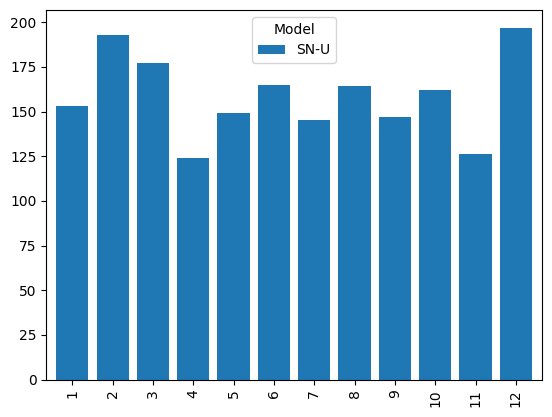

In [ ]:
df.T.plot(kind='bar', width=.8)